# Logistic Regression from Scratch

This notebook follows the same pipeline as the linear regression lesson:

1. Start with a bad model.
2. Make predictions.
3. Calculate likelihood and log-likelihood.
4. Calculate gradients.
5. Update the parameters.
6. Repeat and visualize learning.

We use binary classification:

$$
y \in \{0,1\}
$$

Example:

- $y=0$: fail
- $y=1$: pass

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Logistic regression with one feature

Feature:

- $x$: study hours

Target:

- $y=0$: fail
- $y=1$: pass

The model first computes a linear score:

$$
z = wx + b
$$

Then it converts the score into a probability using the sigmoid function:

$$
\hat{p} = \sigma(z) = \frac{1}{1+e^{-z}}
$$

### 1.1 Tiny dataset

In [2]:
x = np.array([1, 2, 3, 4, 5, 6], dtype=float)
y = np.array([0, 0, 0, 1, 1, 1], dtype=float)

print("x:", x)
print("y:", y)

x: [1. 2. 3. 4. 5. 6.]
y: [0. 0. 0. 1. 1. 1.]


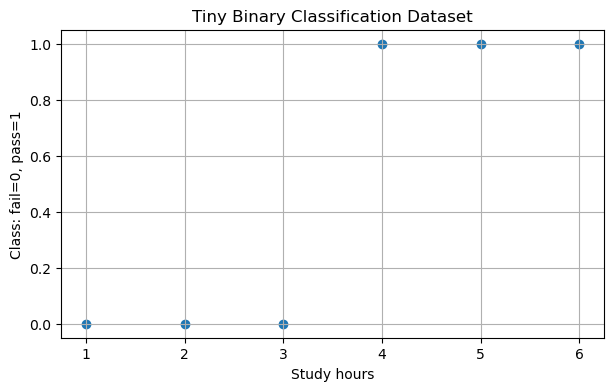

In [3]:
plt.figure(figsize=(7, 4))
plt.scatter(x, y)
plt.xlabel("Study hours")
plt.ylabel("Class: fail=0, pass=1")
plt.title("Tiny Binary Classification Dataset")
plt.grid(True)
plt.show()

### 1.2 Sigmoid function

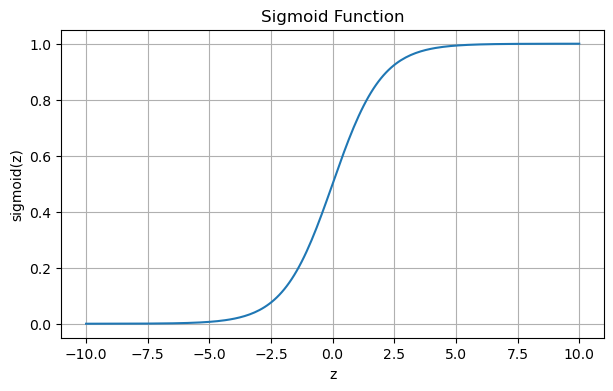

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 200)
p_values = sigmoid(z_values)

plt.figure(figsize=(7, 4))
plt.plot(z_values, p_values)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid(True)
plt.show()

### 1.3 Start with a bad prediction

Start with:

$$
w = 0, \quad b = 0
$$

So:

$$
z = 0 \cdot x + 0 = 0
$$

For every input:

$$
\hat{p} = \sigma(0) = \frac{1}{1+e^{-0}} = 0.5
$$

The model predicts probability 0.5 for every example, so it is completely unsure.

In [5]:
w = 0.0
b = 0.0

z = w * x + b
p = sigmoid(z)

for xi, yi, zi, pi in zip(x, y, z, p):
    print(f"x={xi:.0f}, true y={yi:.0f}, z={zi:.1f}, predicted probability={pi:.3f}")

x=1, true y=0, z=0.0, predicted probability=0.500
x=2, true y=0, z=0.0, predicted probability=0.500
x=3, true y=0, z=0.0, predicted probability=0.500
x=4, true y=1, z=0.0, predicted probability=0.500
x=5, true y=1, z=0.0, predicted probability=0.500
x=6, true y=1, z=0.0, predicted probability=0.500


Initial predictions:

| x | true y | z = wx+b | predicted probability |
|---:|---:|---:|---:|
| 1 | 0 | 0 | 0.5 |
| 2 | 0 | 0 | 0.5 |
| 3 | 0 | 0 | 0.5 |
| 4 | 1 | 0 | 0.5 |
| 5 | 1 | 0 | 0.5 |
| 6 | 1 | 0 | 0.5 |

### 1.4 Likelihood

For one data point:

$$
P(y_i \mid x_i) = \hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}
$$

This means:

- if $y_i=1$, use $\hat{p}_i$
- if $y_i=0$, use $1-\hat{p}_i$

At the beginning, every $\hat{p}_i = 0.5$.

So for each example, the probability of the correct label is 0.5.

The likelihood is:

$$
L = 0.5 \times 0.5 \times 0.5 \times 0.5 \times 0.5 \times 0.5
$$

$$
L = 0.5^6 = 0.015625
$$

In maximum likelihood estimation, we want to make this value larger.

In [6]:
likelihood_values = (p ** y) * ((1 - p) ** (1 - y))
likelihood = np.prod(likelihood_values)

print("Probability of correct label for each example:")
print(likelihood_values)
print("\nTotal likelihood:", likelihood)

Probability of correct label for each example:
[0.5 0.5 0.5 0.5 0.5 0.5]

Total likelihood: 0.015625


### 1.5 Log-likelihood and negative log-likelihood

The log-likelihood is:

$$
\ell(w,b)=
\sum_{i=1}^{n}
\left[
y_i\log(\hat{p}_i)+(1-y_i)\log(1-\hat{p}_i)
\right]
$$

At the beginning:

$$
\hat{p}_i = 0.5
$$

So each example contributes:

$$
\log(0.5) = -0.6931
$$

There are 6 examples:

$$
\ell(w,b) = 6 \times (-0.6931) = -4.1589
$$

In maximum log-likelihood estimation, we want to make this value larger.

For gradient descent, we usually minimize a loss, so we use the negative average log-likelihood:

$$
J(w,b) = -\frac{1}{n}\ell(w,b)
$$

$$
J(w,b) = -\frac{1}{6}(-4.1589) = 0.6931
$$

In [7]:
eps = 1e-15
p_safe = np.clip(p, eps, 1 - eps)

log_likelihood_terms = y * np.log(p_safe) + (1 - y) * np.log(1 - p_safe)
log_likelihood = np.sum(log_likelihood_terms)
negative_average_log_likelihood = -np.mean(log_likelihood_terms)

print("Log-likelihood terms:")
print(log_likelihood_terms)
print("\nTotal log-likelihood:", log_likelihood)
print("\nNegative average log-likelihood:", negative_average_log_likelihood)

Log-likelihood terms:
[-0.69314718 -0.69314718 -0.69314718 -0.69314718 -0.69314718 -0.69314718]

Total log-likelihood: -4.1588830833596715

Negative average log-likelihood: 0.6931471805599453


### 1.6 First gradient descent update with actual values

The gradients are:

$$
gradient_w =
\frac{1}{n}\sum_{i=1}^{n}(\hat{p}_i-y_i)x_i
$$

$$
gradient_b =
\frac{1}{n}\sum_{i=1}^{n}(\hat{p}_i-y_i)
$$

At the beginning:

$$
\hat{p} = [0.5,0.5,0.5,0.5,0.5,0.5]
$$

$$
y = [0,0,0,1,1,1]
$$

So:

$$
\hat{p}-y = [0.5,0.5,0.5,-0.5,-0.5,-0.5]
$$

For $w$:

$$
gradient_w =
\frac{1}{6}
[(0.5)(1)+(0.5)(2)+(0.5)(3)+(-0.5)(4)+(-0.5)(5)+(-0.5)(6)]
$$

$$
gradient_w =
\frac{1}{6}
[0.5+1.0+1.5-2.0-2.5-3.0]
$$

$$
gradient_w = \frac{-4.5}{6} = -0.75
$$

For $b$:

$$
gradient_b =
\frac{1}{6}
[0.5+0.5+0.5-0.5-0.5-0.5] = 0
$$

Use learning rate:

$$
\alpha = 0.5
$$

Update:

$$
w_{new} = 0 - 0.5(-0.75) = 0.375
$$

$$
b_{new} = 0 - 0.5(0) = 0
$$

In [8]:
learning_rate = 0.5

error_probability = p - y

grad_w = np.mean(error_probability * x)
grad_b = np.mean(error_probability)

new_w = w - learning_rate * grad_w
new_b = b - learning_rate * grad_b

print("p - y:", error_probability)
print("gradient_w:", grad_w)
print("gradient_b:", grad_b)
print("\nUpdated parameters:")
print("new w:", new_w)
print("new b:", new_b)

p - y: [ 0.5  0.5  0.5 -0.5 -0.5 -0.5]
gradient_w: -0.75
gradient_b: 0.0

Updated parameters:
new w: 0.375
new b: 0.0


### 1.7 Check the model after one update

Now the model is:

$$
z = 0.375x + 0
$$

In [9]:
w = new_w
b = new_b

z = w * x + b
p = sigmoid(z)

for xi, yi, zi, pi in zip(x, y, z, p):
    print(f"x={xi:.0f}, true y={yi:.0f}, z={zi:.3f}, predicted probability={pi:.3f}")

x=1, true y=0, z=0.375, predicted probability=0.593
x=2, true y=0, z=0.750, predicted probability=0.679
x=3, true y=0, z=1.125, predicted probability=0.755
x=4, true y=1, z=1.500, predicted probability=0.818
x=5, true y=1, z=1.875, predicted probability=0.867
x=6, true y=1, z=2.250, predicted probability=0.905


The model now gives higher probabilities to larger \(x\) values. It is still not perfect, so we continue training.

### 1.8 Train for many epochs

In [10]:
def binary_cross_entropy(y_true, p_pred):
    eps = 1e-15
    p_pred = np.clip(p_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(p_pred) + (1 - y_true) * np.log(1 - p_pred))

w = 0.0
b = 0.0
learning_rate = 0.5
epochs = 100

loss_history = []
w_history = []
b_history = []

for epoch in range(epochs):
    z = w * x + b
    p = sigmoid(z)

    loss = binary_cross_entropy(y, p)

    grad_w = np.mean((p - y) * x)
    grad_b = np.mean(p - y)

    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b

    loss_history.append(loss)
    w_history.append(w)
    b_history.append(b)

    if epoch < 10 or (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}: w={w:.4f}, b={b:.4f}, loss={loss:.4f}")

print("\nFinal model:")
print(f"z = {w:.4f} * x + {b:.4f}")

Epoch   1: w=0.3750, b=0.0000, loss=0.6931
Epoch   2: w=0.1876, b=-0.1347, loss=0.6476
Epoch   3: w=0.2813, b=-0.1970, loss=0.5980
Epoch   4: w=0.2574, b=-0.2862, loss=0.5823
Epoch   5: w=0.2988, b=-0.3576, loss=0.5684
Epoch   6: w=0.3053, b=-0.4359, loss=0.5557
Epoch   7: w=0.3297, b=-0.5080, loss=0.5438
Epoch   8: w=0.3445, b=-0.5809, loss=0.5323
Epoch   9: w=0.3637, b=-0.6511, loss=0.5214
Epoch  10: w=0.3803, b=-0.7204, loss=0.5109
Epoch  20: w=0.5375, b=-1.3393, loss=0.4266
Epoch  30: w=0.6698, b=-1.8519, loss=0.3689
Epoch  40: w=0.7834, b=-2.2863, loss=0.3276
Epoch  50: w=0.8827, b=-2.6625, loss=0.2966
Epoch  60: w=0.9709, b=-2.9942, loss=0.2726
Epoch  70: w=1.0502, b=-3.2911, loss=0.2534
Epoch  80: w=1.1224, b=-3.5601, loss=0.2377
Epoch  90: w=1.1888, b=-3.8064, loss=0.2245
Epoch 100: w=1.2503, b=-4.0337, loss=0.2132

Final model:
z = 1.2503 * x + -4.0337


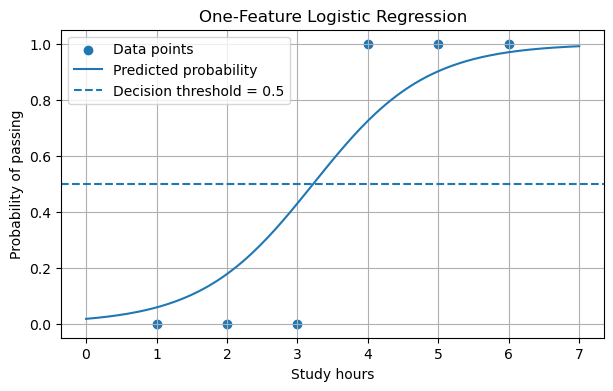

In [11]:
x_line = np.linspace(0, 7, 200)
p_line = sigmoid(w * x_line + b)

plt.figure(figsize=(7, 4))
plt.scatter(x, y, label="Data points")
plt.plot(x_line, p_line, label="Predicted probability")
plt.axhline(0.5, linestyle="--", label="Decision threshold = 0.5")
plt.xlabel("Study hours")
plt.ylabel("Probability of passing")
plt.title("One-Feature Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

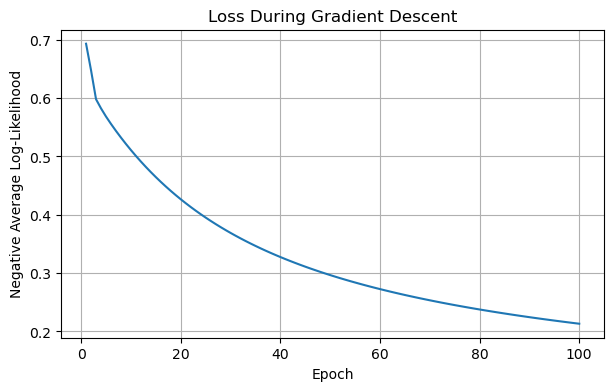

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("Negative Average Log-Likelihood")
plt.title("Loss During Gradient Descent")
plt.grid(True)
plt.show()

In [13]:
p_final = sigmoid(w * x + b)
y_pred = (p_final >= 0.5).astype(int)

for xi, yi, pi, ypi in zip(x, y, p_final, y_pred):
    print(f"x={xi:.1f}, true y={int(yi)}, predicted probability={pi:.3f}, predicted class={ypi}")

x=1.0, true y=0, predicted probability=0.058, predicted class=0
x=2.0, true y=0, predicted probability=0.178, predicted class=0
x=3.0, true y=0, predicted probability=0.430, predicted class=0
x=4.0, true y=1, predicted probability=0.725, predicted class=1
x=5.0, true y=1, predicted probability=0.902, predicted class=1
x=6.0, true y=1, predicted probability=0.970, predicted class=1


## 2. Logistic regression with two features

Now we extend the same idea to two features.

Features:

- $x_1$: study hours
- $x_2$: practice exercises completed

Target:

- $y=0$: fail
- $y=1$: pass

The model is:

$$
z = w_1x_1 + w_2x_2 + b
$$

Then:

$$
\hat{p} = \sigma(z)
$$

### 2.1 Tiny dataset with two features

In [14]:
X = np.array([
    [1, 1],
    [2, 1],
    [2, 2],
    [3, 2],
    [4, 3],
    [5, 3],
    [5, 4],
    [6, 5]
], dtype=float)

y2 = np.array([0, 0, 0, 0, 1, 1, 1, 1], dtype=float)

print("X:")
print(X)
print("y:", y2)

X:
[[1. 1.]
 [2. 1.]
 [2. 2.]
 [3. 2.]
 [4. 3.]
 [5. 3.]
 [5. 4.]
 [6. 5.]]
y: [0. 0. 0. 0. 1. 1. 1. 1.]


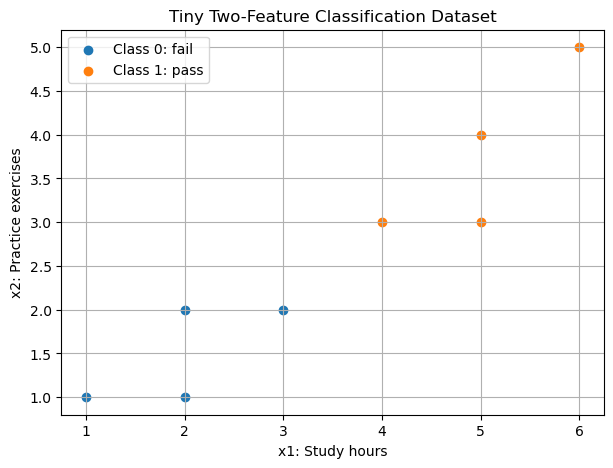

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(X[y2 == 0, 0], X[y2 == 0, 1], label="Class 0: fail")
plt.scatter(X[y2 == 1, 0], X[y2 == 1, 1], label="Class 1: pass")
plt.xlabel("x1: Study hours")
plt.ylabel("x2: Practice exercises")
plt.title("Tiny Two-Feature Classification Dataset")
plt.legend()
plt.grid(True)
plt.show()

### 2.2 Start with a bad prediction

Start with:

$$
w_1 = 0, \quad w_2 = 0, \quad b = 0
$$

So:

$$
z = 0x_1 + 0x_2 + 0 = 0
$$

Therefore:

$$
\hat{p} = \sigma(0) = 0.5
$$

The model predicts 0.5 for every example.

In [16]:
w_vec = np.array([0.0, 0.0])
b2 = 0.0

z = X @ w_vec + b2
p = sigmoid(z)

for row, yi, zi, pi in zip(X, y2, z, p):
    print(
        f"x1={row[0]:.0f}, x2={row[1]:.0f}, true y={yi:.0f}, "
        f"z={zi:.1f}, predicted probability={pi:.3f}"
    )

x1=1, x2=1, true y=0, z=0.0, predicted probability=0.500
x1=2, x2=1, true y=0, z=0.0, predicted probability=0.500
x1=2, x2=2, true y=0, z=0.0, predicted probability=0.500
x1=3, x2=2, true y=0, z=0.0, predicted probability=0.500
x1=4, x2=3, true y=1, z=0.0, predicted probability=0.500
x1=5, x2=3, true y=1, z=0.0, predicted probability=0.500
x1=5, x2=4, true y=1, z=0.0, predicted probability=0.500
x1=6, x2=5, true y=1, z=0.0, predicted probability=0.500


### 2.3 Likelihood and log-likelihood with actual values

There are 8 examples.

At the beginning, each predicted probability is 0.5.

So the probability of each correct label is also 0.5.

Likelihood:

$$
L = 0.5^8 = 0.00390625
$$

Log-likelihood:

$$
\ell = 8 \times \log(0.5)
$$

$$
\ell = 8 \times (-0.6931) = -5.5452
$$

Negative average log-likelihood:

$$
J = -\frac{1}{8}(-5.5452) = 0.6931
$$

In [17]:
likelihood_values = (p ** y2) * ((1 - p) ** (1 - y2))
likelihood = np.prod(likelihood_values)

p_safe = np.clip(p, 1e-15, 1 - 1e-15)
log_likelihood_terms = y2 * np.log(p_safe) + (1 - y2) * np.log(1 - p_safe)
log_likelihood = np.sum(log_likelihood_terms)
negative_average_log_likelihood = -np.mean(log_likelihood_terms)

print("Probability of correct label for each example:")
print(likelihood_values)
print("\nTotal likelihood:", likelihood)
print("\nTotal log-likelihood:", log_likelihood)
print("\nNegative average log-likelihood:", negative_average_log_likelihood)

Probability of correct label for each example:
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]

Total likelihood: 0.00390625

Total log-likelihood: -5.545177444479562

Negative average log-likelihood: 0.6931471805599453


### 2.4 First gradient descent update with actual values

The gradients are:

$$
gradient_{w_1}
=
\frac{1}{n}
\sum_{i=1}^{n}
(\hat{p}_i-y_i)x_{i1}
$$

$$
gradient_{w_2}
=
\frac{1}{n}
\sum_{i=1}^{n}
(\hat{p}_i-y_i)x_{i2}
$$

$$
gradient_b
=
\frac{1}{n}
\sum_{i=1}^{n}
(\hat{p}_i-y_i)
$$

At the beginning:

$$
\hat{p}-y =
[0.5,0.5,0.5,0.5,-0.5,-0.5,-0.5,-0.5]
$$

For $w_1$:

$$
gradient_{w_1}
=
\frac{1}{8}
[(0.5)(1)+(0.5)(2)+(0.5)(2)+(0.5)(3)+(-0.5)(4)+(-0.5)(5)+(-0.5)(5)+(-0.5)(6)]
$$

$$
gradient_{w_1}
=
\frac{1}{8}
[0.5 + 1 + 1 + 1.5 - 2 - 2.5 - 2.5 - 3]
$$

$$
gradient_{w_1} = \frac{-5}{8} = -0.625
$$

For $w_2$:

$$
gradient_{w_2}
=
\frac{1}{8}
[(0.5)(1)+(0.5)(1)+(0.5)(2)+(0.5)(2)+(-0.5)(3)+(-0.5)(3)+(-0.5)(4)+(-0.5)(5)]
$$

$$
gradient_{w_2}
=
\frac{1}{8}
[0.5 + 0.5 + 1 + 1 - 1.5 - 1.5 - 2 - 2.5]
$$

$$
gradient_{w_2} = \frac{-4.5}{8} = -0.5625
$$

For $b$:

$$
gradient_b =
\frac{1}{8}
[0.5 + 0.5 + 0.5 + 0.5 - 0.5 - 0.5 - 0.5 - 0.5]
=0
$$

Use learning rate:

$$
\alpha = 0.3
$$

Update $w_1$:

$$
w_{1,new} = 0 - 0.3(-0.625) = 0.1875
$$

Update $w_2$:

$$
w_{2,new} = 0 - 0.3(-0.5625) = 0.16875
$$

Update $b$:

$$
b_{new} = 0 - 0.3(0) = 0
$$

In [18]:
learning_rate = 0.3

error_probability = p - y2

grad_w = (X.T @ error_probability) / len(X)
grad_b = np.mean(error_probability)

new_w_vec = w_vec - learning_rate * grad_w
new_b2 = b2 - learning_rate * grad_b

print("p - y:")
print(error_probability)
print("\ngradient_w1:", grad_w[0])
print("gradient_w2:", grad_w[1])
print("gradient_b:", grad_b)
print("\nUpdated parameters:")
print("new w1:", new_w_vec[0])
print("new w2:", new_w_vec[1])
print("new b:", new_b2)

p - y:
[ 0.5  0.5  0.5  0.5 -0.5 -0.5 -0.5 -0.5]

gradient_w1: -0.75
gradient_w2: -0.5625
gradient_b: 0.0

Updated parameters:
new w1: 0.22499999999999998
new w2: 0.16874999999999998
new b: 0.0


### 2.5 Check the model after one update

Now the model is:

$$
z = 0.1875x_1 + 0.16875x_2 + 0
$$

In [19]:
w_vec = new_w_vec
b2 = new_b2

z = X @ w_vec + b2
p = sigmoid(z)

for row, yi, zi, pi in zip(X, y2, z, p):
    print(
        f"x1={row[0]:.0f}, x2={row[1]:.0f}, true y={yi:.0f}, "
        f"z={zi:.3f}, predicted probability={pi:.3f}"
    )

x1=1, x2=1, true y=0, z=0.394, predicted probability=0.597
x1=2, x2=1, true y=0, z=0.619, predicted probability=0.650
x1=2, x2=2, true y=0, z=0.787, predicted probability=0.687
x1=3, x2=2, true y=0, z=1.012, predicted probability=0.734
x1=4, x2=3, true y=1, z=1.406, predicted probability=0.803
x1=5, x2=3, true y=1, z=1.631, predicted probability=0.836
x1=5, x2=4, true y=1, z=1.800, predicted probability=0.858
x1=6, x2=5, true y=1, z=2.194, predicted probability=0.900


The higher values of \(x_1\) and \(x_2\) now produce higher probabilities. We continue training.

### 2.6 Train for many epochs

In [20]:
w_vec = np.array([0.0, 0.0])
b2 = 0.0
learning_rate = 0.3
epochs = 200

loss_history_2 = []
w_history_2 = []
b_history_2 = []
n = len(X)

for epoch in range(epochs):
    z = X @ w_vec + b2
    p = sigmoid(z)

    loss = binary_cross_entropy(y2, p)

    grad_w = (X.T @ (p - y2)) / n
    grad_b = np.mean(p - y2)

    w_vec = w_vec - learning_rate * grad_w
    b2 = b2 - learning_rate * grad_b

    loss_history_2.append(loss)
    w_history_2.append(w_vec.copy())
    b_history_2.append(b2)

    if epoch < 10 or (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch+1:3d}: "
            f"w1={w_vec[0]:.4f}, w2={w_vec[1]:.4f}, b={b2:.4f}, loss={loss:.4f}"
        )

print("\nFinal model:")
print(f"z = {w_vec[0]:.4f} * x1 + {w_vec[1]:.4f} * x2 + {b2:.4f}")

Epoch   1: w1=0.2250, w2=0.1687, b=0.0000, loss=0.6931
Epoch   2: w1=0.1292, w2=0.0961, b=-0.0774, loss=0.6376
Epoch   3: w1=0.1618, w2=0.1195, b=-0.1218, loss=0.6033
Epoch   4: w1=0.1598, w2=0.1170, b=-0.1741, loss=0.5937
Epoch   5: w1=0.1721, w2=0.1251, b=-0.2222, loss=0.5850
Epoch   6: w1=0.1788, w2=0.1290, b=-0.2710, loss=0.5767
Epoch   7: w1=0.1875, w2=0.1344, b=-0.3187, loss=0.5686
Epoch   8: w1=0.1954, w2=0.1392, b=-0.3661, loss=0.5607
Epoch   9: w1=0.2035, w2=0.1441, b=-0.4127, loss=0.5530
Epoch  10: w1=0.2115, w2=0.1488, b=-0.4589, loss=0.5455
Epoch  20: w1=0.2878, w2=0.1930, b=-0.8904, loss=0.4795
Epoch  40: w1=0.4218, w2=0.2655, b=-1.6163, loss=0.3859
Epoch  60: w1=0.5346, w2=0.3235, b=-2.2053, loss=0.3243
Epoch  80: w1=0.6306, w2=0.3721, b=-2.6974, loss=0.2814
Epoch 100: w1=0.7136, w2=0.4143, b=-3.1192, loss=0.2499
Epoch 120: w1=0.7863, w2=0.4522, b=-3.4882, loss=0.2258
Epoch 140: w1=0.8507, w2=0.4869, b=-3.8164, loss=0.2068
Epoch 160: w1=0.9084, w2=0.5191, b=-4.1122, loss=

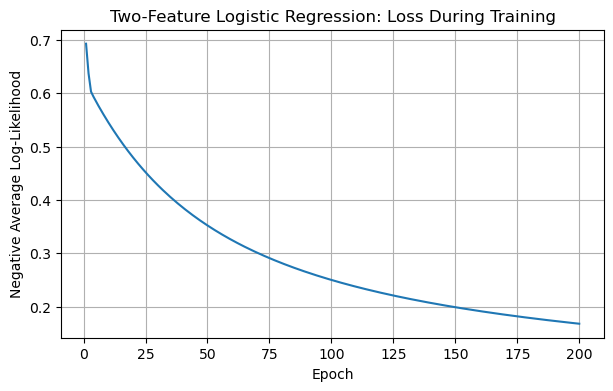

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), loss_history_2)
plt.xlabel("Epoch")
plt.ylabel("Negative Average Log-Likelihood")
plt.title("Two-Feature Logistic Regression: Loss During Training")
plt.grid(True)
plt.show()

### 2.7 Visualize the decision boundary

The decision boundary is where the predicted probability is 0.5.

For the sigmoid function, this happens when:

$$
z = 0
$$

So:

$$
w_1x_1 + w_2x_2 + b = 0
$$

Solving for $x_2$:

$$
x_2 = -\frac{w_1x_1+b}{w_2}
$$

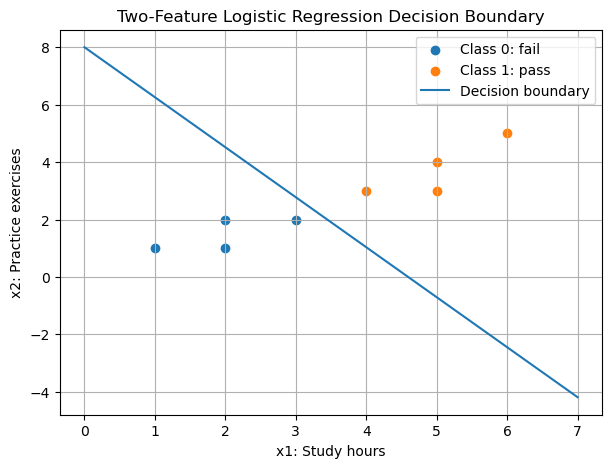

In [22]:
plt.figure(figsize=(7, 5))

plt.scatter(X[y2 == 0, 0], X[y2 == 0, 1], label="Class 0: fail")
plt.scatter(X[y2 == 1, 0], X[y2 == 1, 1], label="Class 1: pass")

x1_line = np.linspace(0, 7, 100)

if abs(w_vec[1]) > 1e-8:
    x2_line = -(w_vec[0] * x1_line + b2) / w_vec[1]
    plt.plot(x1_line, x2_line, label="Decision boundary")

plt.xlabel("x1: Study hours")
plt.ylabel("x2: Practice exercises")
plt.title("Two-Feature Logistic Regression Decision Boundary")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
p_final_2 = sigmoid(X @ w_vec + b2)
y_pred_2 = (p_final_2 >= 0.5).astype(int)

for row, yi, pi, ypi in zip(X, y2, p_final_2, y_pred_2):
    print(
        f"x1={row[0]:.1f}, x2={row[1]:.1f}, "
        f"true y={int(yi)}, predicted probability={pi:.3f}, predicted class={ypi}"
    )

x1=1.0, x2=1.0, true y=0, predicted probability=0.046, predicted class=0
x1=2.0, x2=1.0, true y=0, predicted probability=0.116, predicted class=0
x1=2.0, x2=2.0, true y=0, predicted probability=0.189, predicted class=0
x1=3.0, x2=2.0, true y=0, predicted probability=0.390, predicted class=0
x1=4.0, x2=3.0, true y=1, predicted probability=0.757, predicted class=1
x1=5.0, x2=3.0, true y=1, predicted probability=0.895, predicted class=1
x1=5.0, x2=4.0, true y=1, predicted probability=0.938, predicted class=1
x1=6.0, x2=5.0, true y=1, predicted probability=0.987, predicted class=1


## 3. Optional: Compare with scikit-learn

In real projects, we usually do not implement logistic regression manually.

We use libraries such as scikit-learn.

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y2)

print("scikit-learn coefficients:", model.coef_)
print("scikit-learn intercept:", model.intercept_)

print("\nPredicted probabilities:")
print(model.predict_proba(X))

print("\nPredicted classes:")
print(model.predict(X))

scikit-learn coefficients: [[1.00808019 0.7145717 ]]
scikit-learn intercept: [-5.33087999]

Predicted probabilities:
[[0.9736152  0.0263848 ]
 [0.9308711  0.0691289 ]
 [0.86825031 0.13174969]
 [0.70630307 0.29369693]
 [0.30045002 0.69954998]
 [0.1354934  0.8645066 ]
 [0.07123922 0.92876078]
 [0.01351351 0.98648649]]

Predicted classes:
[0. 0. 0. 0. 1. 1. 1. 1.]


## 4. Summary

Logistic regression has a similar pipeline to linear regression:

| Step | Linear Regression | Logistic Regression |
|---|---|---|
| Score | \(z = wx + b\) | \(z = wx + b\) |
| Output | continuous number | probability |
| Function after score | none | sigmoid |
| Task | regression | binary classification |
| Objective | minimize MSE | maximize likelihood / log-likelihood |
| Practical loss | MSE | negative log-likelihood / binary cross-entropy |

Important idea:

> Logistic regression starts with a linear score, then uses the sigmoid function to convert it into a probability.

Beginner explanation:

> Linear regression predicts a number.  
> Logistic regression predicts a probability.  
> If the probability is at least 0.5, we predict class 1.  
> Otherwise, we predict class 0.

## 5. References and further learning resources

Start with official scikit-learn resources:

1. **scikit-learn: LogisticRegression API documentation**  
   https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

2. **scikit-learn User Guide: Linear Models**  
   https://scikit-learn.org/stable/modules/linear_model.html

3. **scikit-learn: Supervised Learning Guide**  
   https://scikit-learn.org/stable/supervised_learning.html

4. **scikit-learn: Getting Started**  
   https://scikit-learn.org/stable/getting_started.html

Additional beginner-friendly resources:

5. **Inria scikit-learn course: Linear models for classification**  
   https://inria.github.io/scikit-learn-mooc/python_scripts/logistic_regression.html

6. **StatQuest: Logistic Regression**  
   Search for: `StatQuest Logistic Regression`

7. **3Blue1Brown: Neural Networks and Gradient Descent**  
   Helpful for intuition about gradients and optimization.

8. **Andrew Ng Machine Learning Specialization**  
   Helpful for maximum likelihood, logistic regression, and classification intuition.

Suggested next lesson:

- classification metrics:
  - accuracy,
  - precision,
  - recall,
  - F1-score,
  - confusion matrix,
  - ROC curve.